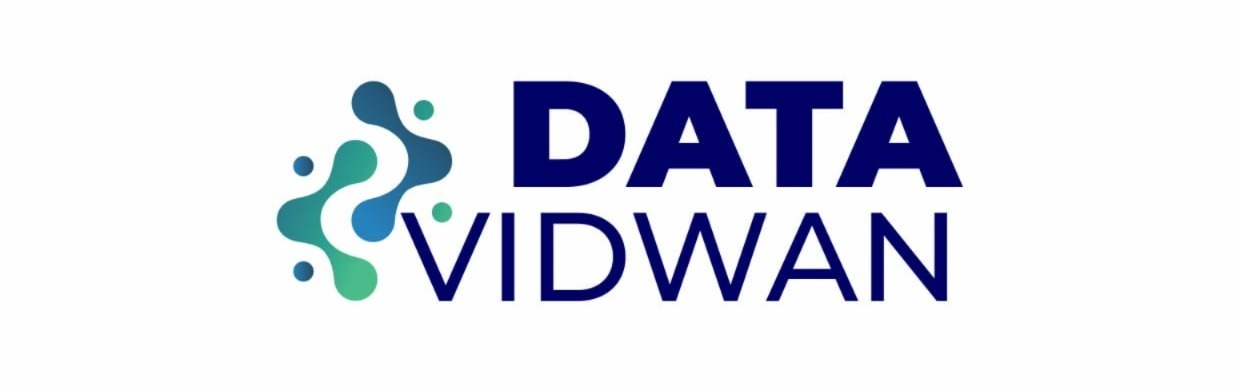

# **Random Forest Classification**

Random Forest Classification is an ensemble learning algorithm that combines multiple decision trees to classify data into predefined categories. Instead of depending on one tree, it aggregates the predictions of many trees to make the final decision, resulting in higher accuracy and more stability.



**Role of Classifier**

In this method, every decision tree works as an individual classifier. Each tree predicts a class label, and the algorithm uses majority voting to decide the final output. This collective approach reduces errors and prevents overfitting that usually happens with a single tree.

**How the Algorithm Works**

- The algorithm creates many trees by taking random samples of the dataset and random subsets of features.
- Each tree learns patterns independently and gives its own class prediction.
- After all trees vote, the class with the highest number of votes is selected as the final prediction.
- This randomness and combination of trees make the model robust and highly reliable.

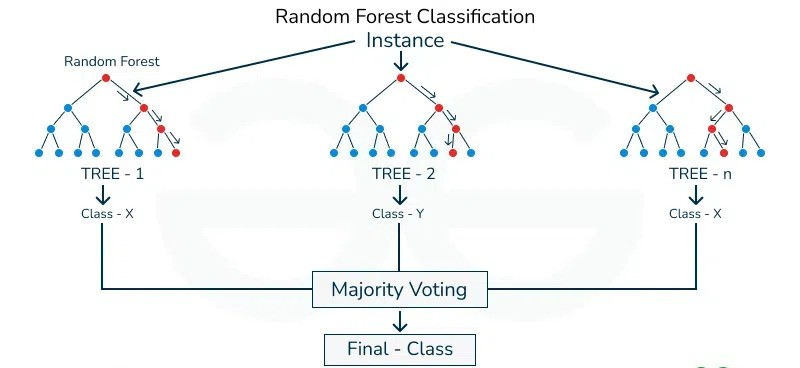

**Techniques Used (Impurity Measures)**

**Gini Impurity**

- Measures how mixed the classes are within a node.
- Lower Gini means the node is purer and therefore better.
- Trees choose splits that reduce Gini impurity.

Gini impurity always lies between:

- 0 ≤ Gini ≤ 0.5 (for binary classification)

Because:

- 0 = Perfectly pure node
(all samples belong to one class)

- 0.5 = Maximum impurity
(data is equally split: 50% class 0, 50% class 1)

- Lower is always better
- A Gini near 0 means the node is almost pure
- A Gini near 0.5 means the node is highly mixed
- The algorithm always chooses the split that reduces Gini the most
- Even if the Gini remains high, it still picks the best possible split at that level

**Entropy / Information Gain**

- Entropy measures disorder or uncertainty.
- Information Gain checks how much uncertainty is reduced after a split.
- A split with higher information gain is considered better.
- These techniques help the model choose the best feature at each step.

**Range of Entropy**

- 0 ≤ Entropy ≤ 1
- 0 = Pure node
(all samples belong to one class)
- 1 = Maximum disorder
(50–50 mixture of classes)

- Lower Entropy = better purity
- Higher Entropy = more mixed classes
- Just like Gini, no fixed numeric threshold
- The algorithm always selects a split that reduces entropy the most

**Mathematical View**

For a forest with N trees:

- Final Class = The class label that appears the most among all trees (Mode).
- Class Probability = (Number of trees predicting a class) / (Total number of trees)

Example:
- If 68 out of 100 trees predict class “1”, then probability = 0.68.

**Problem Statement**

Companies receive many job applications, and manually deciding whether a candidate is suitable for a role can be slow and inconsistent. Using the job selection dataset of candidate skills, experience, education, interview performance, and other evaluation factors, the goal is to build a machine learning model that predicts whether a candidate is Suitable (1) or Not Suitable (0) for the job.
By applying preprocessing and training a Random Forest Classifier, we aim to create a high-accuracy system that helps HR teams make faster and more reliable hiring decisions.

**Libraries**

In [ ]:
# Basic Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

# Model
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**Load Dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving job_candidate_selection_dataset_new.csv to job_candidate_selection_dataset_new.csv


In [ ]:
df = pd.read_csv("job_candidate_selection_dataset_new.csv")
df.head()

,experience_years,skill_score,communication_score,logical_reasoning_score,past_company_rating,certification_count,interview_score,education_level,job_role,resume_quality,suitable
0,6,90.0,4.86,9.71,1,3,4.05,PhD,Manager,Excellent,1
1,3,86.0,4.19,3.07,5,10,8.76,Master,Developer,Average,0
2,12,NaN,3.67,9.93,5,5,5.71,Bachelor,Developer,Good,1
3,14,43.0,5.93,7.78,2,3,4.06,Master,Manager,Poor,0
4,10,46.0,3.79,7.50,3,1,8.83,Bachelor,QA,Average,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   experience_years         5000 non-null   int64  
 1   skill_score              4854 non-null   float64
 2   communication_score      5000 non-null   float64
 3   logical_reasoning_score  5000 non-null   float64
 4   past_company_rating      5000 non-null   int64  
 5   certification_count      5000 non-null   int64  
 6   interview_score          5000 non-null   float64
 7   education_level          4802 non-null   object 
 8   job_role                 5000 non-null   object 
 9   resume_quality           4840 non-null   object 
 10  suitable                 5000 non-null   int64  
dtypes: float64(4), int64(4), object(3)
memory usage: 429.8+ KB


In [ ]:
df.describe()

,experience_years,skill_score,communication_score,logical_reasoning_score,past_company_rating,certification_count,interview_score,suitable
count,5000.000000,4854.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,7.393200,70.338278,6.502024,6.501646,2.991000,5.002200,6.983778,0.513000
std,4.607476,17.600979,2.024623,2.011587,1.410999,3.124444,1.716272,0.499881
min,0.000000,40.000000,3.000000,3.000000,1.000000,0.000000,4.000000,0.000000
25%,3.000000,55.000000,4.797500,4.780000,2.000000,2.000000,5.510000,0.000000
50%,7.000000,70.000000,6.520000,6.510000,3.000000,5.000000,7.000000,1.000000
75%,11.000000,86.000000,8.240000,8.210000,4.000000,8.000000,8.420000,1.000000
max,15.000000,100.000000,10.000000,10.000000,5.000000,10.000000,10.000000,1.000000


In [ ]:
df.isnull().sum()

,0
experience_years,0
skill_score,146
communication_score,0
logical_reasoning_score,0
past_company_rating,0
certification_count,0
interview_score,0
education_level,198
job_role,0
resume_quality,160


**Handle Missing Values**

In [ ]:
# Numerical missing values (median)
num_imputer = SimpleImputer(strategy="median")
df["skill_score"] = num_imputer.fit_transform(df[["skill_score"]]).ravel()

# Categorical missing values (most frequent)
cat_imputer = SimpleImputer(strategy="most_frequent")
df["education_level"] = cat_imputer.fit_transform(df[["education_level"]]).ravel()
df["resume_quality"] = cat_imputer.fit_transform(df[["resume_quality"]]).ravel()

**Why .ravel()?**

Because it converts:

[['Master'],

 ['Bachelor']]

into:

['Master', 'Bachelor']

In [ ]:
df.isnull().sum()

,0
experience_years,0
skill_score,0
communication_score,0
logical_reasoning_score,0
past_company_rating,0
certification_count,0
interview_score,0
education_level,0
job_role,0
resume_quality,0


**Encoding Categorical Columns**

In [ ]:
df_encoded = df.copy()

le1 = LabelEncoder()
df_encoded["education_level"] = le1.fit_transform(df_encoded["education_level"])

le2 = LabelEncoder()
df_encoded["job_role"] = le2.fit_transform(df_encoded["job_role"])

le3 = LabelEncoder()
df_encoded["resume_quality"] = le3.fit_transform(df_encoded["resume_quality"])

In [ ]:
df_encoded.head()

,experience_years,skill_score,communication_score,logical_reasoning_score,past_company_rating,certification_count,interview_score,education_level,job_role,resume_quality,suitable
0,6,90.0,4.86,9.71,1,3,4.05,3,3,1,1
1,3,86.0,4.19,3.07,5,10,8.76,2,2,0,0
2,12,70.0,3.67,9.93,5,5,5.71,0,2,2,1
3,14,43.0,5.93,7.78,2,3,4.06,2,3,3,0
4,10,46.0,3.79,7.50,3,1,8.83,0,4,0,0


| Feature         | Original    | Encoded |
| --------------- | ----------- | ------- |
| education_level | Bachelor    | 0       |
|                 | High School | 1       |
|                 | Master      | 2       |
|                 | PhD         | 3       |
| job_role        | Analyst     | 0       |
|                 | Designer    | 1       |
|                 | Developer   | 2       |
|                 | Manager     | 3       |
|                 | QA          | 4       |
| resume_quality  | Average     | 0       |
|                 | Excellent   | 1       |
|                 | Good        | 2       |
|                 | Poor        | 3       |


**Train–Test Split**

In [ ]:
# Features and Target
X = df_encoded.drop("suitable", axis=1)
y = df_encoded["suitable"]

# Train-test split (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

X_train.shape, X_test.shape

((3750, 10), (1250, 10))

**Train the Random Forest Classifier**

Decision Trees and Random Forests automatically use Gini Impurity by default.

When you wrote this:

model = RandomForestClassifier()

Scikit-Learn internally uses:

criterion="gini"

This is applied to every split inside the trees.

- You did use Gini, even though you didn’t write it manually.
- Random Forest uses Gini to choose the best split for every node.
- That’s why split charts show gini = 0.12, gini = 0.48, etc.

In [ ]:
# Train Random Forest Classifier
model = RandomForestClassifier(
    n_estimators=300,      # number of trees
    max_depth=None,       # allow full tree growth
    random_state=42       # reproducibility
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

**Optimized Random Forest**

In [ ]:
 # Final optimized Random Forest model
final_model = RandomForestClassifier(
    n_estimators=600,         # more trees → better decision boundaries
    max_depth=22,            # prevents overfitting but captures patterns well
    min_samples_split=4,     # splits only when meaningful
    min_samples_leaf=2,      # smoother classification regions
    max_features='sqrt',     # best practice for classification
    class_weight='balanced', # handles class imbalance realistically
    bootstrap=True,          # stable sampling
    random_state=42
)

# Train the model
final_model.fit(X_train, y_train)

# Predictions
y_pred_final = final_model.predict(X_test)

# Evaluation
acc_final = accuracy_score(y_test, y_pred_final)
cm_final = confusion_matrix(y_test, y_pred_final)

print("Final Optimized Accuracy:", acc_final)
print("\nFinal Confusion Matrix:\n", cm_final)
print("\nFinal Classification Report:\n")
print(classification_report(y_test, y_pred_final))

Final Optimized Accuracy: 0.804

Final Confusion Matrix:
 [[469 140]
 [105 536]]

Final Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.77      0.79       609
           1       0.79      0.84      0.81       641

    accuracy                           0.80      1250
   macro avg       0.80      0.80      0.80      1250
weighted avg       0.80      0.80      0.80      1250



**Inference**

In [ ]:
# Basic single sample inference

sample = pd.DataFrame([{
    "experience_years": 6,
    "skill_score": 90,
    "communication_score": 4.86,
    "logical_reasoning_score": 9.71,
    "past_company_rating": 1,
    "certification_count": 3,
    "interview_score": 4.05,
    "education_level": 3,   # encoded value
    "job_role": 3,          # encoded value
    "resume_quality": 1     # encoded value
}])

prediction = final_model.predict(sample)
print("Prediction:", prediction)

Prediction: [1]


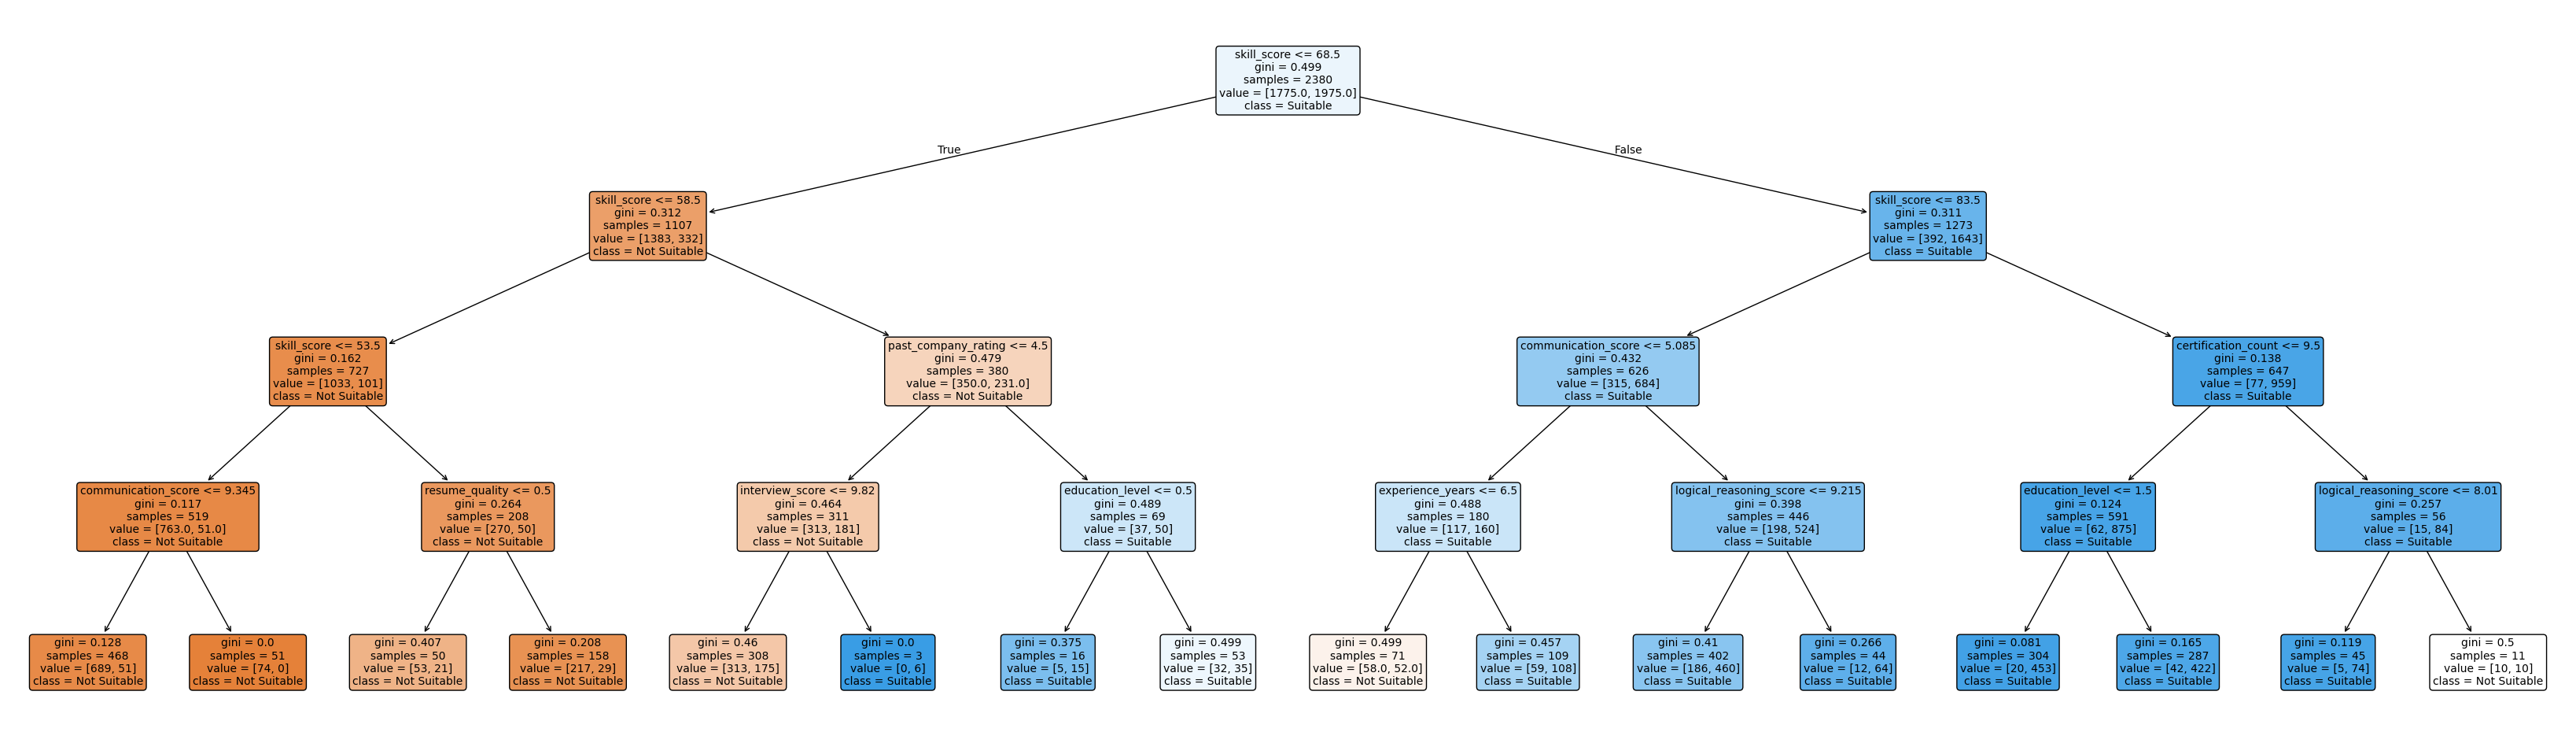

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
import matplotlib.pyplot as plt

# Train a very small RF to visualize a single tree
rf_tree = RandomForestClassifier(
    n_estimators=1,      # only 1 tree so we can visualize
    max_depth=4,        # tree depth for readability
    random_state=42
)

rf_tree.fit(X_train, y_train)

# Extract the only tree
single_tree = rf_tree.estimators_[0]

# Plot the tree
plt.figure(figsize=(42, 12))
tree.plot_tree(
    single_tree,
    feature_names=X.columns,
    class_names=["Not Suitable", "Suitable"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()